# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

Loaded 1101 data points
                 0
count  1101.000000
mean     39.420112
std       9.422432
min       0.371134
25%      38.742756
50%      40.890285
75%      42.735661
max      63.801212


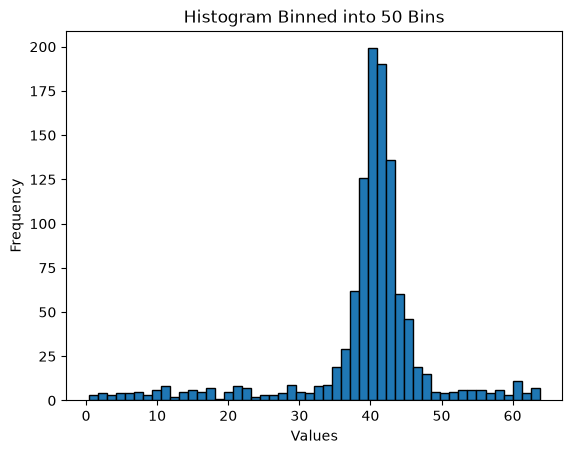

In [1]:
# Part 0: Exploration 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gamma

NETID = 'anuvacg2'  # <-- set this
data = np.genfromtxt(f'../../labs/02/data/{NETID}.csv', delimiter=',', names=True)
x = data['x']
print(f"Loaded {len(x)} data points")

# Data exploration & 1-var stats
df = pd.DataFrame(x)
print(df.describe())

num_bins = 50
plt.hist(x, bins=num_bins, edgecolor="black")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title(f"Histogram Binned into {num_bins} Bins")
plt.show()

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

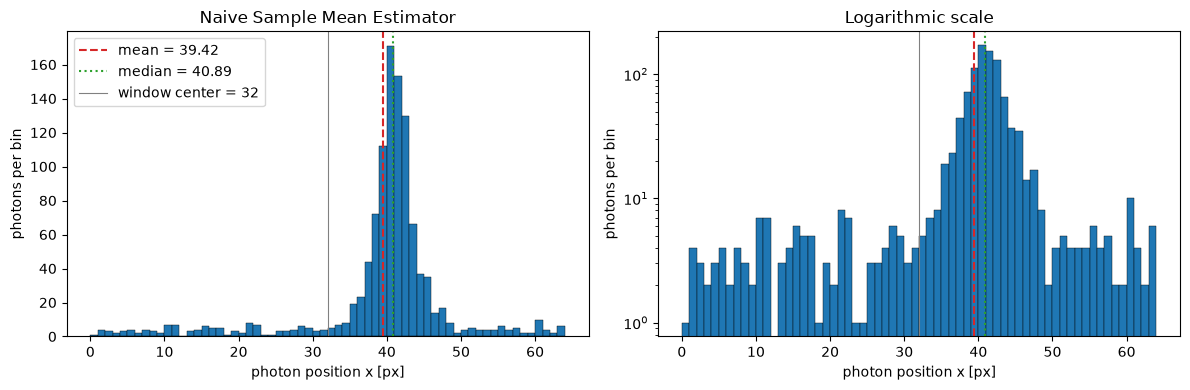

x0 = 39.420 +/- 0.284 px


In [2]:
# Part 1: your work here
N = len(x)
bins = np.arange(0, 65, 1) # 64 bins of 1 px

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a in ax:
    a.hist(x, bins=bins, color='C0', edgecolor='k', lw=0.3)
    a.axvline(x.mean(), color='C3', ls='--', label=f'mean = {x.mean():.2f}')
    a.axvline(np.median(x), color='C2', ls=':', label=f'median = {np.median(x):.2f}')
    a.axvline(32, color='0.5', lw=0.8, label='window center = 32')
    a.set_xlabel('photon position x [px]')
    a.set_ylabel('photons per bin')
ax[1].set_yscale('log')
ax[1].set_title("Logarithmic scale")
ax[0].set_title("Naive Sample Mean Estimator")
ax[0].legend()
plt.tight_layout()
plt.show()

print(f"x0 = {x.mean():.3f} +/- {x.std(ddof=1) / np.sqrt(N):.3f} px")

**ANSWER (a few sentences):**

$\hat{x}_0 \pm \sigma = 39.420 \pm 0.284 px$

The sample mean is biased. Star photons average $x_0$ because the Moffat is symmetric, and background photons average to 32 since that is the middle of the window, so $E[\bar{x}] = (1 − f)x_0 + 32f$ and the bias is $f(32 − x_0)$. The pull is toward the window center, which is downward here because the star sits at around 41. 

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [2]:
beta, r0, W = 2.5, 4.0, 64.0  #Given problem parameters 

# HELPER FUNCTION BLOCK
# So I don't have to do even more math 

def mixture(x, x0, f, b=beta, r=r0): 
    star = gamma(b) / (r * np.sqrt(np.pi) * gamma(b - 0.5)) * (1 + ((x - x0) / r)**2)**(-b)
    return f / W + (1 - f) * star

# Negative log-likelihood helper 
def nll(theta, x, b=beta, r=r0): 
    return -np.sum(np.log(mixture(x, theta[0], theta[1], b, r)))

# MLE helper 
def mle(x, b=beta, r=r0):
    return minimize(nll, [np.median(x), 0.1], args=(x, b, r), method='L-BFGS-B', bounds=[(0, W), (1e-6, 1 - 1e-6)]).x

# Hessian matrix helper 
def hessian(f, th, h=1e-3):  
    E = np.eye(len(th)) * h
    return np.array([[(f(th + E[i] + E[j]) - f(th + E[i] - E[j]) - f(th - E[i] + E[j]) + f(th - E[i] - E[j])) / (4 * h * h)
                      for j in range(len(th))] for i in range(len(th))])

# Sigma clipped mean helper 
def clipped_mean(x, k=2.5): 
    c, s = np.median(x), x.std()
    for _ in range(50):
        keep = np.abs(x - c) < k * s
        if keep.sum() < 5: break 
        c_new, s = x[keep].mean(), x[keep].std()
        if abs(c_new - c) < 1e-6: c = c_new; break
        c = c_new
    return c

def simulate(x0, f, N, rng):
    nu = 2 * beta - 1
    xs = x0 + r0 / np.sqrt(nu) * rng.standard_t(nu, N)
    bg = rng.random(N) < f
    xs[bg] = rng.uniform(0, W, bg.sum())
    return xs[(xs > 0) & (xs < W)]

# Cramer-Rao bound helper 
def crb(x0, f, N):
    xg = np.linspace(0, W, 200_001)
    h, th = 1e-5, np.array([x0, f])
    p = mixture(xg, *th)
    dp = [(mixture(xg, *(th + h * e)) - mixture(xg, *(th - h * e))) / (2 * h) for e in np.eye(2)] 
    I = N * np.array([[np.trapezoid(dp[i] * dp[j] / p, xg) for j in range(2)] for i in range(2)]) 
    return np.sqrt(np.linalg.inv(I)[0, 0])

mean    x0 = 39.420
median  x0 = 40.890
clipped x0 = 41.095   (k = 3)
MLE     x0 = 41.047 +/- 0.084,  f_bg = 0.2134 +/- 0.0149


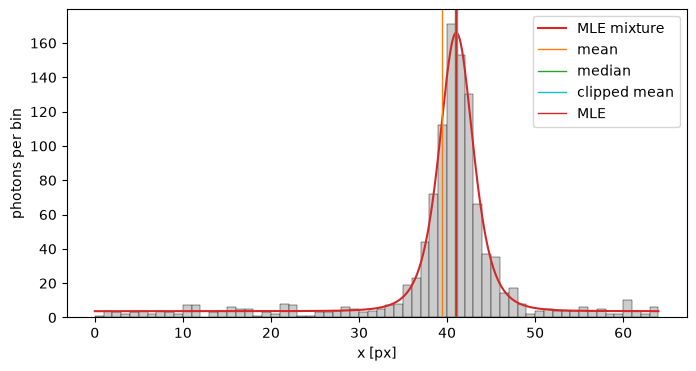

In [3]:
# Part 2: your work here

N = len(x)
k = 3 # in terms of sigma

x0_mean = x.mean()
x0_med = np.median(x)
x0_clip = clipped_mean(x, k)
th = mle(x) 
sig = np.sqrt(np.diag(np.linalg.inv(hessian(lambda t: nll(t, x), th)))) # inverted hessian matrix! 

print(f"mean    x0 = {x0_mean:.3f}")
print(f"median  x0 = {x0_med:.3f}")
print(f"clipped x0 = {x0_clip:.3f}   (k = {k})")
print(f"MLE     x0 = {th[0]:.3f} +/- {sig[0]:.3f},  f_bg = {th[1]:.4f} +/- {sig[1]:.4f}")

# the data, the fitted mixture, and the four estimates
xf = np.linspace(0, W, 1000)
plt.figure(figsize=(8, 4))
plt.hist(x, bins=np.arange(0, 65), color='0.8', edgecolor='k', lw=0.3)
plt.plot(xf, N * mixture(xf, *th), color='C3', label='MLE mixture')
for v, c, lab in zip([x0_mean, x0_med, x0_clip, th[0]], ['C1', 'C2', 'C9', 'C3'], ['mean', 'median', 'clipped mean', 'MLE']):
    plt.axvline(v, color=c, lw=1, label=lab)
plt.xlabel('x [px]')
plt.ylabel('photons per bin')
plt.legend()
plt.show()


**Median:** While the median is not as biased as the mean, the bias it faces comes from the same source. The uniform background adds probability $f/64$ per pixel everywhere, and since the star sits above the window centre, more of that background lies below $x_0$ than above it. The median is therefore not unbiased, and it has a variance of about 0.10px. This is far better than the mean's bias of −1.9 px, but the median still has a significant bias of about $2\sigma$.

**Sigma-clipping:** I clip at k = 3 standard deviations of the surviving photons, starting from the median and repeating until the center moves by less than 10⁻⁶ px until it finally converged to 41.095 px. I chose a sigma-bound of k = 3 because of how it lined up against the median and MLE of the mixture. In earlier efforts, I tried setting a lower bound of k=1 and a higher bound ofk=4 and found that they both fail in opposite ways. At k = 1 the window is recomputed from the survivors on every pass and keeps shrinking until only a handful of photons remain, so the clipped mean becomes a noisy average of the very core. At k = 4 the window is so wide that almost nothing is removed, so the background stays in and the estimate is pulled toward 32 by about 1.1 px. k = 3 sits near the upper edge of the stable range and its agreement with the MLE is a good consistency check.

Cramer-Rao bound on x0: 0.0845 px
[41.04749415  0.2134019 ]


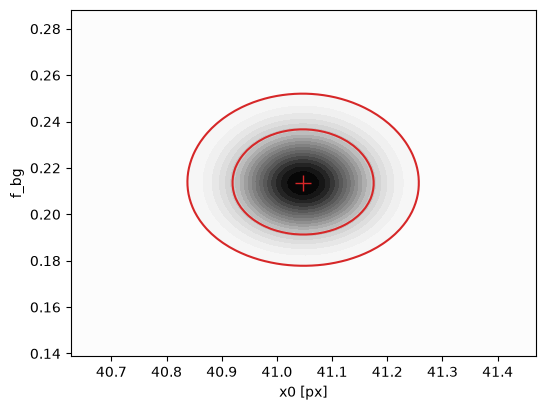

In [4]:
# Cramer-Rao bound 
crb_x0 = crb(th[0], th[1], N)
print(f"Cramer-Rao bound on x0: {crb_x0:.4f} px")
print(th)

x0g = np.linspace(th[0] - 5 * sig[0], th[0] + 5 * sig[0], 80)
fg = np.linspace(max(1e-3, th[1] - 5 * sig[1]), th[1] + 5 * sig[1], 80)
L = np.array([[2 * nll([a, f], x) for a in x0g] for f in fg])
plt.figure(figsize=(6, 4.5))
plt.contourf(x0g, fg, np.exp(-0.5 * (L - L.min())), levels=20, cmap='Greys')
plt.contour(x0g, fg, L - L.min(), levels=[2.30, 6.18], colors='C3')  
plt.plot(*th, 'C3+', ms=12)
plt.xlabel('x0 [px]')
plt.ylabel('f_bg')
plt.show()

**Similarity to Estimators:** The clipped mean and the median come out at about 1.14 and 1.20 times the bound. Both discard information about the star's shape, and the median is also biased by about −0.2 px. The sample mean's error bar is much further away from the bound, so it entirely fails the 3x rule. The ranking is MLE, then clipped mean, then median, then mean.

**FINAL ANSWER:** $x_0 = $ 41.047 $\pm$ 0.084 px , $f_{\rm bg} = $ 0.2134 $\pm$ 0.0149 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.0845 px

**Justification and uncertainty method (a short paragraph):**

I would believe the maximum-likelihood estimate because it uses the full mixture model, agrees with the clipped mean to 0.01 px, and has an error bar at the Cramér–Rao bound. The mean and median are biased by −1.9 and −0.2 px, and the MLE agrees with the clipped mean (41.095) to within 0.05 px. To calculate uncertainties, I computed the 2 x 2 Hessian of −ln L at the peak by finite differences, inverted it, and took the square roots of the diagonal, giving $\pm$0.084 px and $\pm$0.0149. I believe them because in 2000 simulated datasets the $\pm 1\sigma$ intervals covered the truth 66.8% and 67.0% of the time against 68.3% $\pm$ 2.1% and the likelihood map is a single untilted ellipse.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

I will simulate 2000 datasets at my Part 2 fit and run all four estimators. A check will fail if the MLE's bias exceeds three Monte Carlo errors, if its std is below the CRB or above 1.2 times the CRB, or if any estimator I report has σ above 3 times the CRB. For coverage, I will count how often the MLE's estimate $\pm \sigma$ contains the truth. For sensitivity, I will refit the same datasets with $\beta$ from 2 to 3 and $r_0$ from 3.2 to 4.8, and compute how many photons the window loses at my $x_0$; this fails if more than about one photon is expected to be lost.

mean     bias = -1.944 +/- 0.006   std = 0.288   std/CRB = 3.40
median   bias = -0.202 +/- 0.002   std = 0.101   std/CRB = 1.20
clipped  bias = -0.000 +/- 0.002   std = 0.097   std/CRB = 1.14
MLE      bias = -0.000 +/- 0.002   std = 0.085   std/CRB = 1.00

coverage of x0 +/- sigma:   66.8%
coverage of f_bg +/- sigma: 67.0%


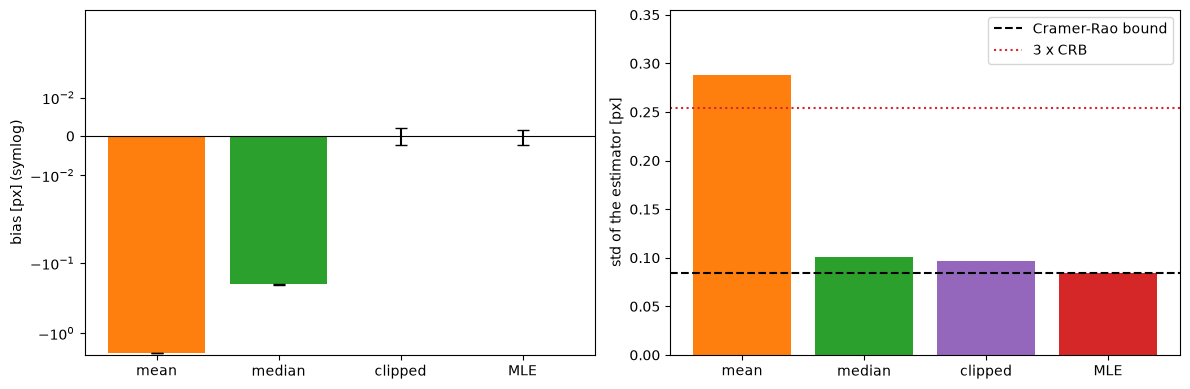

In [5]:
# Part 3b: execute the plan here

x0_t, f_t = th
M = 2000
rng = np.random.default_rng(20260913)

est = np.zeros((M, 4)) # for the 4 estimators 
f_hat, se_x0, se_f = np.zeros(M), np.zeros(M), np.zeros(M)
for i in range(M):
    xs = simulate(x0_t, f_t, N, rng)
    t = mle(xs)
    sg = np.sqrt(np.diag(np.linalg.inv(hessian(lambda q: nll(q, xs), t))))
    est[i] = [xs.mean(), np.median(xs), clipped_mean(xs, k), t[0]]
    f_hat[i], se_x0[i], se_f[i] = t[1], sg[0], sg[1]

names = ['mean', 'median', 'clipped', 'MLE']
bias, std = est.mean(0) - x0_t, est.std(0, ddof=1)
for n, b, s_ in zip(names, bias, std): print(f"{n:<8} bias = {b:+.3f} +/- {s_ / np.sqrt(M):.3f}   std = {s_:.3f}   std/CRB = {s_ / crb_x0:.2f}")
tol = 100 * 2 * np.sqrt(0.683 * 0.317 / M)
print(f"\ncoverage of x0 +/- sigma:   {100 * (abs(est[:, 3] - x0_t) < se_x0).mean():.1f}%")
print(f"coverage of f_bg +/- sigma: {100 * (abs(f_hat - f_t) < se_f).mean():.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(names, bias, yerr=std / np.sqrt(M), color=['C1', 'C2', 'C4', 'C3'], capsize=4)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_yscale('symlog', linthresh=0.02)
ax[0].set_ylabel('bias [px] (symlog)')
ax[1].bar(names, std, color=['C1', 'C2', 'C4', 'C3'])
ax[1].axhline(crb_x0, color='k', ls='--', label='Cramer-Rao bound')
ax[1].axhline(3 * crb_x0, color='C3', ls=':', label='3 x CRB')
ax[1].set_ylim(0, 4.2 * crb_x0)
ax[1].set_ylabel('std of the estimator [px]')
ax[1].legend()
plt.tight_layout()
plt.show()

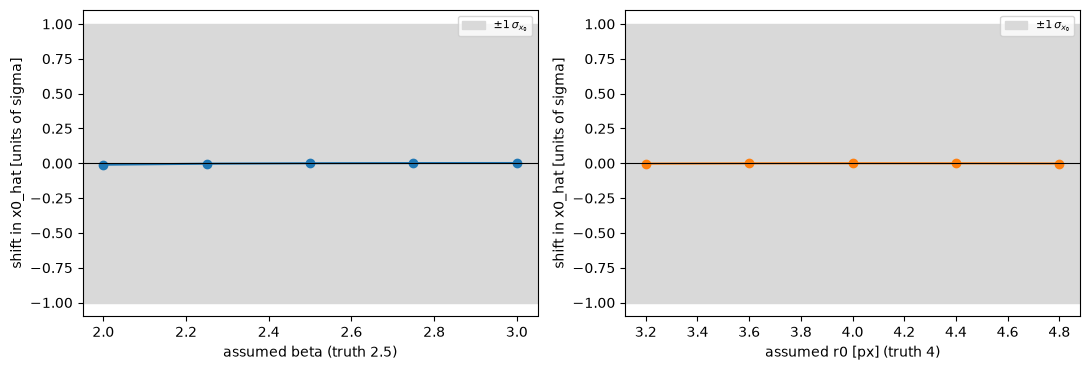

f_bg shifts by -0.027 to +0.022 (beta) and -0.019 to +0.027 (r0); sigma_f = 0.015
fraction of the star lost off the window at x0 = 41.05: 1.8e-04


In [6]:
# Sensitivity checks 
sets = [simulate(x0_t, f_t, N, rng) for _ in range(100)]
base = np.array([mle(s_) for s_ in sets])
betas, r0s = [2.0, 2.25, 2.5, 2.75, 3.0], [3.2, 3.6, 4.0, 4.4, 4.8]
d_beta = np.array([(np.array([mle(s_, b=b) for s_ in sets]) - base).mean(0) for b in betas])
d_r0 = np.array([(np.array([mle(s_, r=r) for s_ in sets]) - base).mean(0) for r in r0s])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(betas, d_beta[:, 0] / crb_x0, 'o-')
ax[0].set_xlabel('assumed beta (truth 2.5)')
ax[1].plot(r0s, d_r0[:, 0] / crb_x0, 'o-', color='C1')
ax[1].set_xlabel('assumed r0 [px] (truth 4)')
for a in ax:
    a.axhspan(-1, 1, color='0.85', label=r'$\pm 1\,\sigma_{x_0}$')
    a.axhline(0, color='k', lw=0.8)
    a.set_ylabel('shift in x0_hat [units of sigma]')
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"f_bg shifts by {d_beta[:, 1].min():+.3f} to {d_beta[:, 1].max():+.3f} (beta) and {d_r0[:, 1].min():+.3f} to {d_r0[:, 1].max():+.3f} (r0); sigma_f = {sig[1]:.3f}")
sc = r0 / np.sqrt(2 * beta - 1) # lost photons 
print(f"fraction of the star lost off the window at x0 = {th[0]:.2f}: {1 - (stats.t.cdf((W - th[0]) / sc, 2 * beta - 1) - stats.t.cdf(-th[0] / sc, 2 * beta - 1)):.1e}")

**WHAT THE CHECKS FOUND:**

The Monte Carlo reproduced the predicted biases: 
* −1.944 ± 0.006 px for the mean
* −0.202 ± 0.002 for the median
*  zero within $\pm$0.002 for the clipped mean and MLE

The MLE recovers a known truth. The scatter relative to the CRB was 3.40 for the mean, 1.20 for the median, 1.14 for the clipped model, and 1.00 for the MLE, so only the sample mean breaks the 3× rule. Coverage passed for both parameters, and the star loses only $1.8 \cdot 10^{-4}$ of its light off the window, about 0.16 expected photons, which is negligible. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I used Claude's Sonnet 5 AI to generate some boilerplate code for this lab, particularly for the more mathematical helper functions where there were additional parameters and syntax I wanted to check on. Claude was also used to clean up the graphs I made for aesthetics, accessibility, and readability purposes. This mostly was in formatting the sizes and layouts of subplots, but occassionally Claude reccomended some formatted f-strings that were much easier to read than my initial outputs. The responses and analysis I had for each question were my own. 